In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor


demand = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/PGCB_date_power_demand.xlsx")
weather = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/weather_data.xlsx")
eco = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/economic_full_1.csv")

to sort the rows by date

In [3]:
demand.sort_values(by="datetime")
demand.reset_index(drop=True, inplace=True)
demand

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN



To handle duplicate values :

here it is just keeping the last value if a duplicate exists



In [4]:


demand = demand.drop_duplicates(subset=["datetime"], keep="last")

demand.duplicated(subset=["datetime"]).sum()

np.int64(0)

In [5]:



column1 = 'generation_mw'
column2 = 'demand_mw'

# Check if there are ANY NaN values in column1
nan_in_column1 = demand[column1].isna().any()

# Check if there are ANY NaN values in column2
nan_in_column2 = demand[column2].isna().any()


if nan_in_column1:
    print(f"There are missing values in the '{column1}' column.")
else:
    print(f"No missing values found in the '{column1}' column.")

if nan_in_column2:
    print(f"There are missing values in the '{column2}' column.")
else:
    print(f"No missing values found in the '{column2}' column.")

if nan_in_column1 or nan_in_column2:
    print(f"\nThere are missing values in at least one of the '{column1}' or '{column2}' columns.")
else:
    print(f"\nNo missing values found in either '{column1}' or '{column2}' columns.")



No missing values found in the 'generation_mw' column.
No missing values found in the 'demand_mw' column.

No missing values found in either 'generation_mw' or 'demand_mw' columns.


Okay ... So there are no missing values yet in any of the columns for demand or generation which is a good sign for us ...


now we check for any spikes and uncertainities between demand and generation

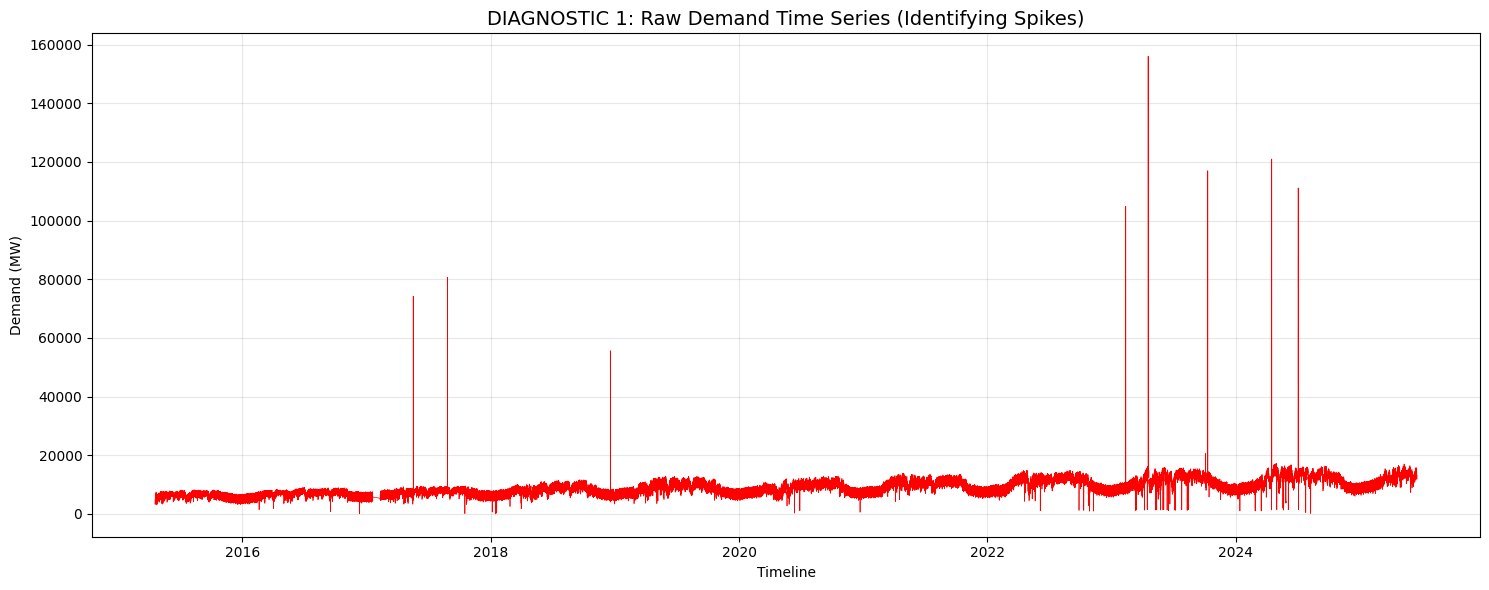

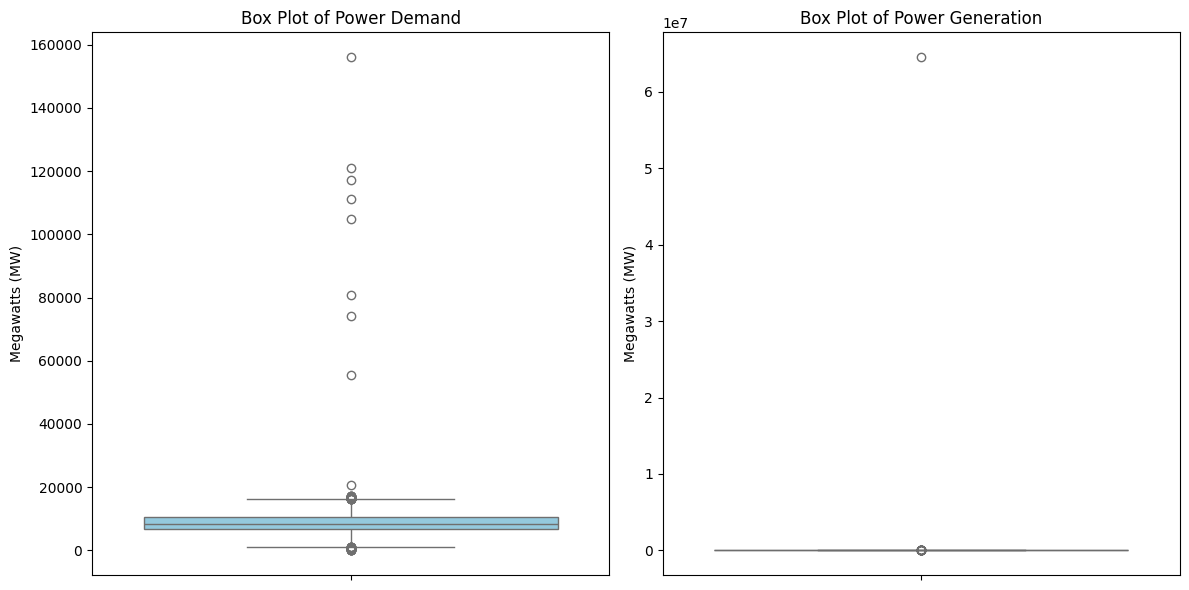

In [6]:



df_raw = demand
df_raw = df_raw.sort_values('datetime')


df_raw['hour'] = df_raw['datetime'].dt.hour
df_raw['month_name'] = df_raw['datetime'].dt.month_name()
df_raw['day_name'] = df_raw['datetime'].dt.day_name()


month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']



plt.figure(figsize=(15, 6))
plt.plot(df_raw['datetime'], df_raw['demand_mw'], color='red', linewidth=0.5)
plt.title('DIAGNOSTIC 1: Raw Demand Time Series (Identifying Spikes)', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() # Or plt.savefig('raw_spikes.png')




df = demand

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
sns.boxplot(y=df['demand_mw'], color='skyblue')
plt.title('Box Plot of Power Demand')
plt.ylabel('Megawatts (MW)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['generation_mw'], color='salmon')
plt.title('Box Plot of Power Generation')
plt.ylabel('Megawatts (MW)')

plt.tight_layout()
plt.show()

The given boxplot and graphs show the effect of outliers on the data .... the sudden spikes in the average as well as yearly values encourage us to first fix the discrepancy in the dataset



*   Demand_mw : there are some points far from the box plots and also the spikes indicate presence of outliers
*   there is a very very high value for generation_mw due to which the box plot feels squashed and the line graph almost feels like a straight line



In [7]:
print(df_raw.generation_mw.describe())
print(df_raw.demand_mw.describe())

count    9.221800e+04
mean     9.438848e+03
std      2.124718e+05
min      7.300000e+01
25%      6.821000e+03
50%      8.419750e+03
75%      1.056400e+04
max      6.452650e+07
Name: generation_mw, dtype: float64
count     92218.000000
mean       8826.045631
std        2772.254531
min           6.000000
25%        6819.000000
50%        8431.000000
75%       10638.000000
max      156050.000000
Name: demand_mw, dtype: float64


In [8]:




def remove_outliers_iqr(demand, column):
    Q1 = demand[column].quantile(0.25)


    Q3 = demand[column].quantile(0.75)

    IQR = Q3 - Q1

    # Defining bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 2 * IQR


    outliers = demand[(demand[column] < lower_bound) | (demand[column] > upper_bound)]
    print(f"Column '{column}': Found {len(outliers)} outliers to nullify.")


    demand.loc[(demand[column] < lower_bound) | (demand[column] > upper_bound), column] = np.nan
    return demand



demand['year'] = demand['datetime'].dt.year


demand = demand.groupby('year', group_keys=False).apply(lambda x: remove_outliers_iqr(x.copy(), 'demand_mw'))
demand = demand.groupby('year', group_keys=False).apply(lambda x: remove_outliers_iqr(x.copy(), 'generation_mw'))


print(f"Total NaNs after cleaning: {demand['demand_mw'].isna().sum()}")


print("Outliers handled! Data is now ready for interpolation.")

Column 'demand_mw': Found 0 outliers to nullify.
Column 'demand_mw': Found 11 outliers to nullify.
Column 'demand_mw': Found 3 outliers to nullify.
Column 'demand_mw': Found 7 outliers to nullify.
Column 'demand_mw': Found 0 outliers to nullify.
Column 'demand_mw': Found 6 outliers to nullify.
Column 'demand_mw': Found 0 outliers to nullify.
Column 'demand_mw': Found 14 outliers to nullify.
Column 'demand_mw': Found 25 outliers to nullify.
Column 'demand_mw': Found 13 outliers to nullify.
Column 'demand_mw': Found 0 outliers to nullify.
Column 'generation_mw': Found 0 outliers to nullify.
Column 'generation_mw': Found 10 outliers to nullify.
Column 'generation_mw': Found 2 outliers to nullify.
Column 'generation_mw': Found 5 outliers to nullify.
Column 'generation_mw': Found 0 outliers to nullify.
Column 'generation_mw': Found 5 outliers to nullify.
Column 'generation_mw': Found 0 outliers to nullify.
Column 'generation_mw': Found 15 outliers to nullify.
Column 'generation_mw': Found 1

/tmp/ipykernel_8254/669927214.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demand['year'] = demand['datetime'].dt.year
/tmp/ipykernel_8254/669927214.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  demand = demand.groupby('year', group_keys=False).apply(lambda x: remove_outliers_iqr(x.copy(), 'demand_mw'))
/tmp/ipykernel_8254/669927214.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

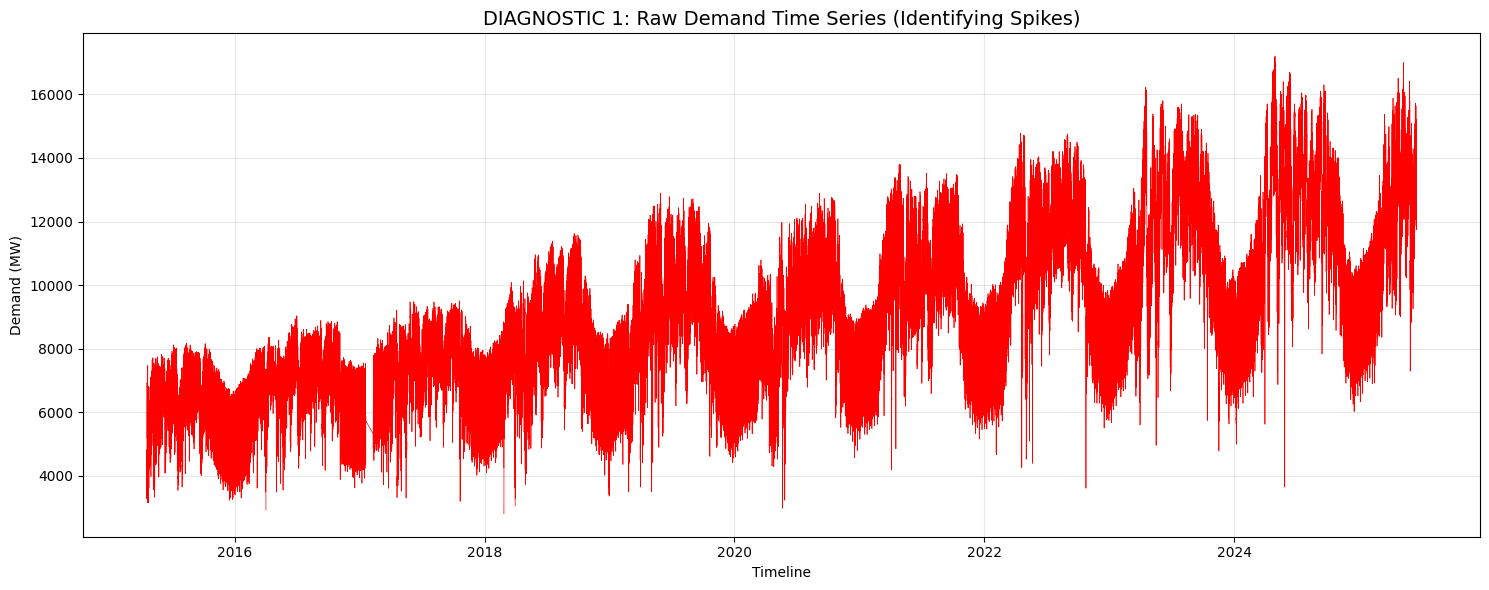

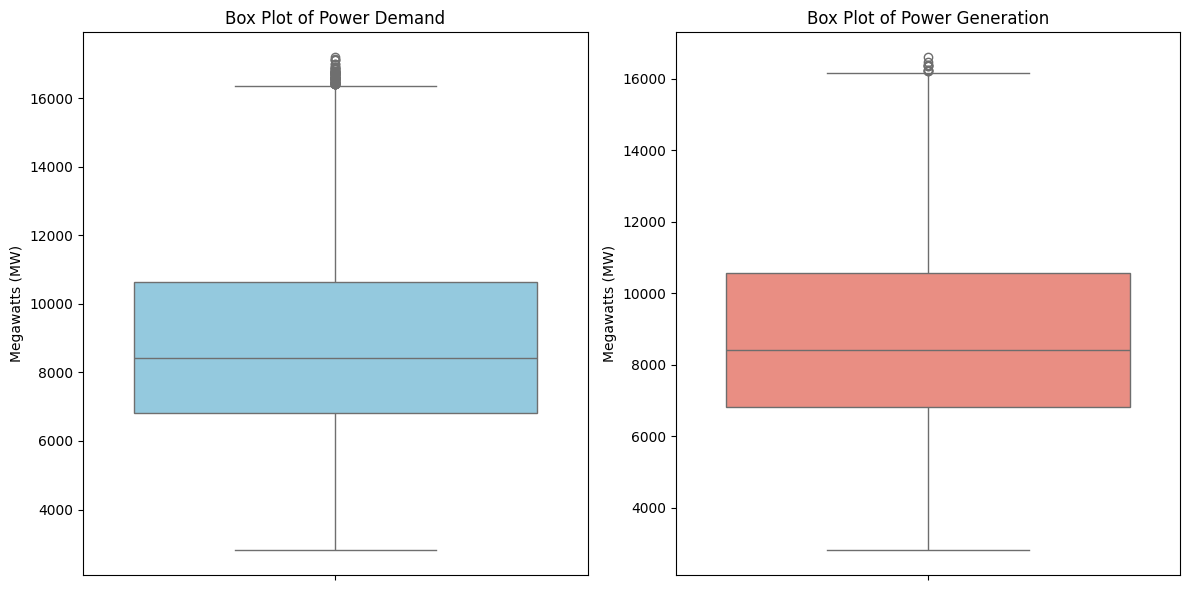

In [9]:
df_raw = demand
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw = df_raw.sort_values('datetime')

df_raw['hour'] = df_raw['datetime'].dt.hour
df_raw['month_name'] = df_raw['datetime'].dt.month_name()
df_raw['day_name'] = df_raw['datetime'].dt.day_name()


month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']



plt.figure(figsize=(15, 6))
plt.plot(df_raw['datetime'], df_raw['demand_mw'], color='red', linewidth=0.5)
plt.title('DIAGNOSTIC 1: Raw Demand Time Series (Identifying Spikes)', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() # Or plt.savefig('raw_spikes.png')




df=df_raw


plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
sns.boxplot(y=df['demand_mw'], color='skyblue')
plt.title('Box Plot of Power Demand')
plt.ylabel('Megawatts (MW)')


plt.subplot(1, 2, 2)
sns.boxplot(y=df['generation_mw'], color='salmon')
plt.title('Box Plot of Power Generation')
plt.ylabel('Megawatts (MW)')

plt.tight_layout()
plt.show()

till now we have sorted , cleaned and removed the duplicates from the data . Also y=using outlier detection we have identified the spikes and filled them with NaN values which we are going to fill in the next step . In the box plot , the values just above the upper line indicate the peak on certain days when demand is very high.

In [10]:
print(demand.isna().sum())

datetime                    0
generation_mw              54
demand_mw                  79
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   21888
wind                    73563
india_bheramara_hvdc        0
india_tripura               0
india_adani             84886
nepal                   86871
remarks                 85850
year                        0
dtype: int64


In [11]:
cols_to_remove = ['solar', 'wind', 'india_adani', 'nepal', 'remarks','gas' , 'liquid_fuel' , 'coal' , 'hydro' , 'solar' , 'wind' , 'india_bheramara_hvdc' , 'india_tripura' , 'india_adani' , 'nepal' , 'remarks']
demand_cleaned = demand.drop(columns=cols_to_remove)

In [12]:
demand_cleaned = demand_cleaned.set_index('datetime')

perfect_range = pd.date_range(start=demand_cleaned.index.min(),
                             end=demand_cleaned.index.max(),
                             freq='h')


demand_cleaned = demand_cleaned.reindex(perfect_range)


print(demand_cleaned.isna().sum())

generation_mw    1108
demand_mw        1131
load_shedding    1055
year             1055
dtype: int64


Now we  transform the hour, day of week, and month into Sine and Cosine waves. This ensures the KNN and Seasonal models understand that December (12) is next to January (1), and Sunday (6) is next to Monday (0).

In [13]:

from sklearn.impute import KNNImputer

demand_cyclic= demand_cleaned.copy()

def apply_cyclic_encoding(df):
    # Hour cycle (24h)
    df['hr_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hr_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    # Day cycle (7 days)
    df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
    # Month cycle (12 months)
    df['mnth_sin'] = np.sin(2 * np.pi * (df.index.month-1) / 12)
    df['mnth_cos'] = np.cos(2 * np.pi * (df.index.month-1) / 12)
    return df

demand_cyclic = apply_cyclic_encoding(demand_cyclic)

### We need to identify the "Islands" (consecutive NaNs) and then apply the strategy:

1. Small Gaps (< 24 hours): Linear Interpolation

In [14]:
# Linear interpolation limited to 4 consecutive hours
demand_cyclic['demand_mw'] = demand_cyclic['demand_mw'].interpolate(method='linear', limit=24)

2. Medium Gaps (24–72 hours): KNN Method
KNN will use the cyclic features we just created to find "similar" hours from the days before/after.

In [15]:
# Identifying the medium-sized gaps
# Calculating the size of each continuous NaN "island"
is_null = demand_cyclic['demand_mw'].isnull()
islands = (is_null != is_null.shift()).cumsum()
island_size = demand_cyclic.groupby(islands)['demand_mw'].transform('count')

medium_mask = (demand_cyclic['demand_mw'].isnull()) & (island_size <= 72)

if medium_mask.any():
    imputer = KNNImputer(n_neighbors=5)
    knn_cols = ['demand_mw', 'hr_sin', 'hr_cos', 'day_sin', 'day_cos', 'mnth_sin', 'mnth_cos']

    #  KNN and applied ONLY to the medium islands
    df_knn = pd.DataFrame(imputer.fit_transform(demand_cyclic[knn_cols]), columns=knn_cols, index=demand_cyclic.index)
    demand_cyclic.loc[medium_mask, 'demand_mw'] = df_knn.loc[medium_mask, 'demand_mw']

3. Large Gaps (> 24 hours): Relative Seasonal Imputation
To make this "relative" (so a 3-month gap in 2024 reflects 2024's growth), we calculate a Seasonal Factor.

Step A: Calculate the average hourly profile (Month + Day + Hour) across the whole dataset.

Step B: Calculate the "Yearly Growth Multiplier" (e.g., 2024 is 1.05x higher than the total average).

Step C: Fill the gap by multiplying the Profile by the Multiplier.

In [16]:

large_mask = demand_cyclic['demand_mw'].isnull()

if large_mask.any():
    # A. The Heartbeat: Avg demand for (Month, DayOfWeek, Hour)
    seasonal_profile = demand_cyclic.groupby([demand_cyclic.index.month, demand_cyclic.index.dayofweek, demand_cyclic.index.hour])['demand_mw'].transform('mean')

    # B. The Relative Factor: Growth of that year vs the overall dataset average
    growth_multiplier = demand_cyclic.groupby(demand_cyclic.index.year)['demand_mw'].transform('mean') / demand_cyclic['demand_mw'].mean()

    # C. Filling the large gaps relatively
    demand_cyclic.loc[large_mask, 'demand_mw'] = seasonal_profile * growth_multiplier

In [17]:
cols_to_fill = [ 'generation_mw','load_shedding' , 'year']

for col in cols_to_fill:
    # 1. Linear (Small)
    demand_cyclic[col] = demand_cyclic[col].interpolate(method='linear', limit=3)

    # 2. KNN (Medium)
    medium_mask = (demand_cyclic[col].isnull()) & (island_size <= 24)
    if medium_mask.any():
        imputer = KNNImputer(n_neighbors=5)

        current_knn_cols = [col, 'hr_sin', 'hr_cos', 'day_sin', 'day_cos', 'mnth_sin', 'mnth_cos']


        df_knn = pd.DataFrame(imputer.fit_transform(demand_cyclic[current_knn_cols]), columns=current_knn_cols, index=demand_cyclic.index)
        demand_cyclic.loc[medium_mask, col] = df_knn.loc[medium_mask, col]


    large_mask = demand_cyclic[col].isnull()
    if large_mask.any():
        seasonal_profile = demand_cyclic.groupby([demand_cyclic.index.month, demand_cyclic.index.dayofweek, demand_cyclic.index.hour])[col].transform('mean')

        growth_multiplier = demand_cyclic.groupby(demand_cyclic.index.year)[col].transform('mean') / demand_cyclic['demand_mw'].mean()

        demand_cyclic.loc[large_mask, col] = seasonal_profile * growth_multiplier

In [18]:
print(demand_cyclic.isna().sum())

generation_mw    0
demand_mw        0
load_shedding    0
year             0
hr_sin           0
hr_cos           0
day_sin          0
day_cos          0
mnth_sin         0
mnth_cos         0
dtype: int64


Now since the missing values are fixed , we plot the graph

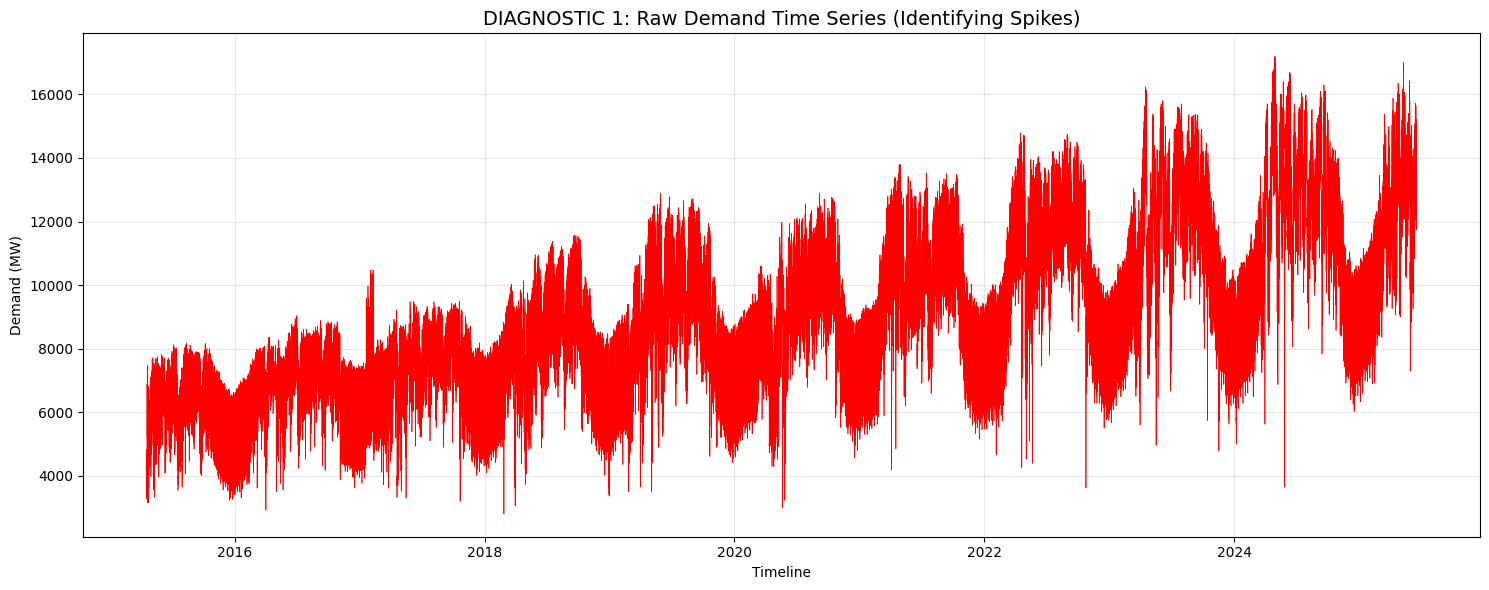

In [19]:
plt.figure(figsize=(15, 6))
plt.plot(demand_cyclic.index, demand_cyclic['demand_mw'], color='red', linewidth=0.5)
plt.title('DIAGNOSTIC 1: Raw Demand Time Series (Identifying Spikes)', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

there was a 3 month gap of almost 1051 hours which i tried to fill using the seasonal imputation



---





---

now we will clean the weather and economics files
and then merge them with the data set



In [20]:

# 1. Load the file skipping the first 2 rows of metadata
# The 'weather' variable is already a DataFrame.
# We need to extract the actual header from the third row (index 2)
# and the data from the fourth row (index 3) onwards.
new_columns = weather.iloc[2].values
weather_df = weather.iloc[3:].copy()
weather_df.columns = new_columns

# 2. Identify and drop unnecessary location columns
# The list of columns to drop refers to metadata columns that would typically be in a raw export.
# After the previous step, `weather_df` has columns like 'time', 'temperature_2m (°C)', etc.
# These metadata columns like 'name', 'address', 'latitude', 'longitude' are no longer present in `weather_df`.
# The list comprehension will correctly filter out non-existent columns.
cols_to_drop = ['name', 'address', 'resolvedAddress', 'latitude', 'longitude']
weather_df = weather_df.drop(columns=[c for c in cols_to_drop if c in weather_df.columns])

# 3. Fix Data Types
# First, rename the 'time' column to 'datetime' for consistency with other dataframes.
weather_df = weather_df.rename(columns={'time': 'datetime'})

for col in weather_df.columns:
    if col == 'datetime': # Check for the renamed 'datetime' column
        weather_df[col] = pd.to_datetime(weather_df[col])
    else:
        # errors='coerce' turns any remaining text into NaN
        weather_df[col] = pd.to_numeric(weather_df[col], errors='coerce')

# 4. Final Cleanup
# Sort by 'datetime' and reset the index.
weather_df = weather_df.sort_values('datetime').reset_index(drop=True)

print("Weather Data Cleaned!")
print(weather_df.info())

Weather Data Cleaned!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107304 entries, 0 to 107303
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   datetime                        107304 non-null  datetime64[ns]
 1   temperature_2m (°C)             107304 non-null  float64       
 2   relative_humidity_2m (%)        107304 non-null  int64         
 3   apparent_temperature (°C)       107304 non-null  float64       
 4   precipitation (mm)              107304 non-null  float64       
 5   dew_point_2m (°C)               107304 non-null  float64       
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  float64       
 7   wind_direction_10m (°)          107304 non-null  int64         
 8   cloud_cover (%)                 107304 non-null  int64         
 9   sunshine_duration (s)           107304 non-null  float64       
dtypes: datetime64[ns](1), float64(6), 

In [21]:
print(weather_df.isna().sum())
print(weather_df.describe())

datetime                          0
temperature_2m (°C)               0
relative_humidity_2m (%)          0
apparent_temperature (°C)         0
precipitation (mm)                0
dew_point_2m (°C)                 0
soil_temperature_0_to_7cm (°C)    0
wind_direction_10m (°)            0
cloud_cover (%)                   0
sunshine_duration (s)             0
dtype: int64
                  datetime  temperature_2m (°C)  relative_humidity_2m (%)  \
count               107304        107304.000000             107304.000000   
mean   2020-02-14 11:30:00            25.457445                 76.806233   
min    2014-01-01 00:00:00             8.400000                 15.000000   
25%    2017-01-22 17:45:00            22.600000                 67.000000   
50%    2020-02-14 11:30:00            26.500000                 81.000000   
75%    2023-03-08 05:15:00            28.800000                 90.000000   
max    2026-03-29 23:00:00            40.800000                100.000000   
std        

In [22]:
expected_range = pd.date_range(start=weather_df['datetime'].min(),
                             end=weather_df['datetime'].max(),
                             freq='h')
weather_df = weather_df.set_index('datetime').reindex(expected_range).interpolate(method='linear').reset_index()



print(weather_df.describe())

                     index  temperature_2m (°C)  relative_humidity_2m (%)  \
count               107304        107304.000000             107304.000000   
mean   2020-02-14 11:30:00            25.457445                 76.806233   
min    2014-01-01 00:00:00             8.400000                 15.000000   
25%    2017-01-22 17:45:00            22.600000                 67.000000   
50%    2020-02-14 11:30:00            26.500000                 81.000000   
75%    2023-03-08 05:15:00            28.800000                 90.000000   
max    2026-03-29 23:00:00            40.800000                100.000000   
std                    NaN             5.033014                 16.454697   

       apparent_temperature (°C)  precipitation (mm)  dew_point_2m (°C)  \
count              107304.000000       107304.000000      107304.000000   
mean                   28.804437            0.205420          20.633153   
min                     6.600000            0.000000           2.500000   
25%   

In [23]:
weather_df_filtered = weather_df[['index', 'temperature_2m (°C)', 'relative_humidity_2m (%)']]
weather_df_filtered = weather_df_filtered.rename(columns={'index': 'datetime'})
display(weather_df_filtered.head())

,datetime,temperature_2m (°C),relative_humidity_2m (%)
0,2014-01-01 00:00:00,13.9,89
1,2014-01-01 01:00:00,13.6,91
2,2014-01-01 02:00:00,13.3,91
3,2014-01-01 03:00:00,13.0,92
4,2014-01-01 04:00:00,12.7,93


weather is filtered and clean now

---



In [24]:
import pandas as pd

# Load economic data
econ_df = eco

target_indicators = [
    'GDP (constant 2015 US$)',
    'Population, total',
    'Manufacturing, value added (% of GDP)'
]


econ_filtered = econ_df[econ_df['Indicator Name'].isin(target_indicators)]


econ_filtered = econ_filtered.drop(columns=['Country Name', 'Indicator Code'])


econ_long = econ_filtered.melt(id_vars=['Indicator Name'],
                                var_name='year',
                                value_name='value')


econ_final = econ_long.pivot(index='year', columns='Indicator Name', values='value').reset_index()


econ_final['year'] = econ_final['year'].astype(int)

econ_final = econ_final[(econ_final['year'] >= 2014) & (econ_final['year'] <= 2026)]

econ_final.columns = ['year', 'gdp_2015_usd', 'manufacturing_pct_gdp', 'population_total']
econ_final = econ_final.ffill()
econ_final.reset_index(drop=True)



,year,gdp_2015_usd,manufacturing_pct_gdp,population_total
0,2014,1.831460e+11,16.612708,157964929.0
1,2015,1.951470e+11,16.788674,159383179.0
2,2016,2.090280e+11,20.347948,160811932.0
3,2017,2.228040e+11,20.075062,162186147.0
4,2018,2.391120e+11,20.802296,163523103.0
5,2019,2.579580e+11,21.207944,164913055.0
6,2020,2.668530e+11,20.598332,166298024.0
7,2021,2.853690e+11,21.235673,167658854.0
8,2022,3.056300e+11,21.764819,169384897.0
9,2023,3.232800e+11,22.342019,171466990.0


In [25]:
# Preserve the datetime index as a column before the merge
demand_cyclic_with_datetime = demand_cyclic.reset_index()


demand_cyclic_with_datetime['year'] = demand_cyclic_with_datetime['index'].dt.year


final_df = pd.merge(demand_cyclic_with_datetime, econ_final, on='year', how='left')


final_df = final_df.drop(columns=['year'])

# Set 'datetime' back as the index for the final DataFrame
final_df = final_df.set_index('index')

print(f"Final dataset range: {econ_final['year'].min()} to {econ_final['year'].max()}")

Final dataset range: 2014 to 2025


### Merging Weather Data

Now that both the demand and economic data (`final_df`) and the filtered weather data (`weather_df_filtered`) are cleaned, we can merge them. We'll join `final_df` (which has 'datetime' as its index) with `weather_df_filtered` (after setting 'datetime' as its index) using a left join to ensure all demand and economic records are kept.

In [26]:
# Set 'datetime' as index for weather_df_filtered to align with final_df's index
weather_df_filtered_indexed = weather_df_filtered.set_index('datetime')

# Perform a left merge based on the datetime index
final_df_merged = final_df.merge(weather_df_filtered_indexed, left_index=True, right_index=True, how='left')

print("Merged final_df with weather data. Displaying the first 5 rows:")
display(final_df_merged.head())

Merged final_df with weather data. Displaying the first 5 rows:


,generation_mw,demand_mw,load_shedding,hr_sin,hr_cos,day_sin,day_cos,mnth_sin,mnth_cos,gdp_2015_usd,manufacturing_pct_gdp,population_total,temperature_2m (°C),relative_humidity_2m (%)
index,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.0,0.0,0.000000,1.000000,-0.781831,0.62349,1.0,6.123234e-17,1.951470e+11,16.788674,159383179.0,25.7,87
2015-04-19 01:00:00,3612.0,3612.0,0.0,0.258819,0.965926,-0.781831,0.62349,1.0,6.123234e-17,1.951470e+11,16.788674,159383179.0,25.3,88
2015-04-19 02:00:00,3727.0,3727.0,0.0,0.500000,0.866025,-0.781831,0.62349,1.0,6.123234e-17,1.951470e+11,16.788674,159383179.0,24.9,90
2015-04-19 03:00:00,3632.0,3632.0,0.0,0.707107,0.707107,-0.781831,0.62349,1.0,6.123234e-17,1.951470e+11,16.788674,159383179.0,25.0,90
2015-04-19 04:00:00,3641.0,3641.0,0.0,0.866025,0.500000,-0.781831,0.62349,1.0,6.123234e-17,1.951470e+11,16.788674,159383179.0,25.2,91


Feature Engineering: The "History" Effect (Lags)
Right now, your model only sees the current temperature and current GDP. But power demand is highly dependent on what happened an hour ago or yesterday.



demand_lag_1h: The demand from 1 hour ago.

demand_lag_24h: The demand from the same time yesterday.

The 168h Anchor: difference between different days of the week

Volatility Awareness: The std and max features allow an XGBoost or Random Forest model to understand if the grid is entering a high-load period versus a stable period.



In [27]:




final_df_merged['demand_lag_1h'] = final_df_merged['demand_mw'].shift(1)
final_df_merged['demand_lag_24h'] = final_df_merged['demand_mw'].shift(24)

final_df_merged['demand_lag_168h'] = final_df_merged['demand_mw'].shift(168)


window = final_df_merged['demand_mw'].rolling(window=24)

final_df_merged['demand_rolling_avg_24h'] = window.mean()

final_df_merged['demand_rolling_std_24h'] = window.std()

final_df_merged['demand_rolling_max_24h'] = window.max()


final_df_merged = final_df_merged.dropna()



In [28]:
print(final_df_merged.isna().sum())

generation_mw               0
demand_mw                   0
load_shedding               0
hr_sin                      0
hr_cos                      0
day_sin                     0
day_cos                     0
mnth_sin                    0
mnth_cos                    0
gdp_2015_usd                0
manufacturing_pct_gdp       0
population_total            0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
demand_lag_1h               0
demand_lag_24h              0
demand_lag_168h             0
demand_rolling_avg_24h      0
demand_rolling_std_24h      0
demand_rolling_max_24h      0
dtype: int64




---

#Model training and testing

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

final_df_merged['target_mw'] = final_df_merged['demand_mw'].shift(-1)

final_df_merged = final_df_merged.dropna(subset=['target_mw'])




X_features = [
   'demand_mw', 'hr_sin','demand_lag_1h', 'demand_lag_24h', 'hr_cos', 'day_sin', 'day_cos', 'mnth_sin', 'mnth_cos',
    'gdp_2015_usd', 'manufacturing_pct_gdp', 'population_total',
    'temperature_2m (°C)', 'relative_humidity_2m (%)'

]


train_mask = final_df_merged.index.year <= 2023
test_mask = final_df_merged.index.year == 2024


y_train = final_df_merged.loc[train_mask, 'target_mw']
y_test = final_df_merged.loc[test_mask, 'target_mw']


X_train = final_df_merged.loc[train_mask, X_features]

X_test = final_df_merged.loc[test_mask, X_features]


#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

X_train_scaled=X_train
X_test_scaled=X_test

#  Training the Model
# Using RandomForest as seen in your notebook imports
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

#  Testing with MAPE
y_pred = model.predict(X_test_scaled)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Model Performance on 2024 Data:")
print(f"MAPE: {mape * 100:.2f}%")
print(f"Accuracy: {100 - (mape * 100):.2f}%")

Model Performance on 2024 Data:
MAPE: 1.84%
Accuracy: 98.16%


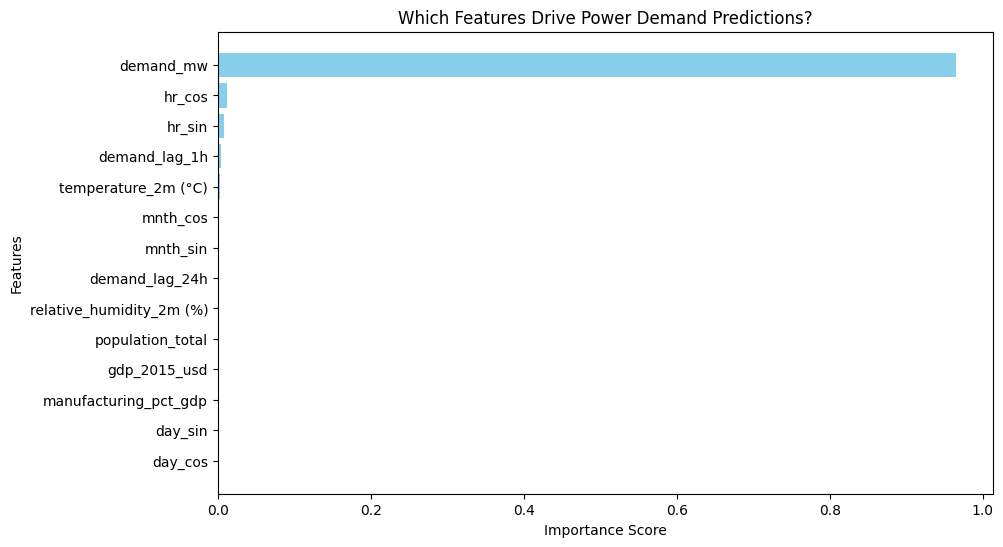

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get importance scores from the trained model
importances = model.feature_importances_
feature_names = X_features # The list of features we defined earlier

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Which Features Drive Power Demand Predictions?')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()